In [1]:
# ==============================
# 📂 Load & Process Data 
# ==============================

import pandas as pd
import numpy as np
import tensorflow as tf
import autokeras as ak
from sklearn.model_selection import train_test_split

def load_data(file_path):
    """
    Load the CSV file containing embeddings and labels.
    """
    df = pd.read_csv(file_path)

    # Convert embeddings from strings to NumPy arrays
    df["embedding"] = df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=","))

    # Convert labels: "1,0" -> 1 (Normal), "0,1" -> 0 (Abnormal)
    df["label"] = df["label"].apply(lambda x: 1 if x == "1,0" else 0)

    # Convert to NumPy arrays
    embeddings = np.stack(df["embedding"].values)
    labels = np.array(df["label"].values)

    # Split into train/test (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, random_state=42
    )

    # Create TensorFlow datasets with consistent batch sizes
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(64).shuffle(1000).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

    
    print(f"✅ Data loaded: {len(X_train)} training samples, {len(X_test)} testing samples")
    
    # Verify shapes
    for x, y in train_ds.take(1):
        print(f"Batch shapes: X={x.shape}, y={y.shape}")
    
    return train_ds, test_ds, X_train.shape[1]

train_ds, test_ds, input_dim = load_data("~/final_merged_data.csv")

2025-02-18 01:35:09.168267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-18 01:35:09.337060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739871309.406233     105 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739871309.424662     105 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-18 01:35:09.575565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

✅ Data loaded: 5464 training samples, 1366 testing samples
Batch shapes: X=(64, 1408), y=(64,)


2025-02-18 01:35:18.230898: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
# ==============================
# 🤖 3️⃣ AutoML Model Selection 
# ==============================


import autokeras as ak
import h2o
from h2o.automl import H2OAutoML
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Option 1: AutoKeras (TensorFlow-based)
def automl_autokeras(train_data, test_data, input_dim, max_trials=20, epochs=50):
    """
    Automated model search with AutoKeras (TensorFlow backend)
    """
    # Initialize AutoModel for structured data
    automodel = ak.StructuredDataClassifier(
        max_trials=max_trials,
        overwrite=True,
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
        directory='automl_models'
    )

    # Convert TF Dataset to numpy arrays (AutoKeras requirement)
    X_train = np.concatenate([x for x, y in train_data], axis=0)
    y_train = np.concatenate([y for x, y in train_data], axis=0)
    
    # Train AutoML model
    automodel.fit(
        X_train,
        y_train,
        epochs=epochs,
        validation_split=0.2,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)]
    )

    # Evaluate on test set
    X_test = np.concatenate([x for x, y in test_data], axis=0)
    y_test = np.concatenate([y for x, y in test_data], axis=0)
    
    best_model = automodel.export_model()
    test_loss, test_acc, test_auc = best_model.evaluate(X_test, y_test)
    
    print(f"\n🔍 AutoKeras Results:")
    print(f"Test Accuracy: {test_acc:.3f} | Test AUC: {test_auc:.3f}")
    
    return best_model

# Option 2: H2O AutoML (Traditional ML)
def automl_h2o(X_train, y_train, X_test, y_test, max_runtime_sec=300):
    """
    Automated model search with H2O AutoML
    """
    # Initialize H2O cluster
    h2o.init(nthreads=-1, enable_assertions=False)
    
    # Convert to H2O Frame
    train_df = pd.DataFrame(X_train)
    train_df['label'] = y_train
    h2o_train = h2o.H2OFrame(train_df)
    h2o_train['label'] = h2o_train['label'].asfactor()
    
    # Configure AutoML
    aml = H2OAutoML(
        max_runtime_secs=max_runtime_sec,
        exclude_algos=["DeepLearning"],
        seed=42,
        nfolds=5
    )
    
    # Train models
    aml.train(y='label', training_frame=h2o_train)
    
    # Evaluate best model
    test_df = pd.DataFrame(X_test)
    test_df['label'] = y_test
    h2o_test = h2o.H2OFrame(test_df)
    
    best_model = aml.leader
    performance = best_model.model_performance(h2o_test)
    
    print("\n🔍 H2O AutoML Results:")
    print(performance)
    
    return best_model



In [2]:
# ==============================
# 🤖 Hybrid AutoML + Custom Architecture
# ==============================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
from sklearn.metrics import roc_auc_score

def hybrid_model_builder(hp):
    """Combines AutoML search with proven architectural patterns"""
    inputs = keras.Input(shape=(input_dim,))
    
    # Architecture inspired by successful model
    x = layers.Dense(
        units=hp.Int('units_1', 512, 2048, step=256),
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(hp.Float('l2_1', 1e-4, 1e-2, sampling='log'))
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(hp.Float('dropout_1', 0.2, 0.5))(x)
    
    # Progressive dimensionality reduction
    for i in range(hp.Int('num_blocks', 2, 4)):
        x = layers.Dense(
            units=hp.Int(f'units_{i+2}', 128, 1024, step=128),
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(hp.Float(f'l2_{i+2}', 1e-4, 1e-2, sampling='log'))
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(hp.Float(f'dropout_{i+2}', 0.2, 0.5))(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    # AutoML-optimized learning parameters
    optimizer = keras.optimizers.Adam(
        learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log'),
        beta_1=hp.Float('beta_1', 0.85, 0.99),
        beta_2=hp.Float('beta_2', 0.9, 0.9999)
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="auc", multi_label=True),
            keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )
    return model

# Initialize Bayesian tuner
tuner = kt.BayesianOptimization(
    hybrid_model_builder,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=50,
    directory="hybrid_automl",
    project_name="optimized_auc"
)

# Callbacks for optimal training
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=10,
        mode="max",
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=5,
        mode="max",
        min_lr=1e-6
    )
]

# Execute search
tuner.search(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=callbacks,
    batch_size=32
)

# Retrieve and evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Final evaluation with proper AUC calculation
X_test = np.concatenate([x for x, y in test_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = best_model.predict(X_test).ravel()

print(f"\n🔍 Final Test AUC: {roc_auc_score(y_test, y_pred):.3f}")


Reloading Tuner from hybrid_automl/optimized_auc/tuner0.json


/home/bahram/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2025-02-18 01:35:20.944202: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
I0000 00:00:1739871321.079893     510 service.cc:148] XLA service 0x7f5594002d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739871321.080541     510 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-02-18 01:35:21.092385: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739871321.142250     510 cuda_dnn.cc:529] Loaded cuDNN

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   

🔍 Final Test AUC: 0.836


In [3]:
# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(train_ds, validation_data=test_ds, epochs=50, callbacks=callbacks)

# Evaluate on test set
auc = best_model.evaluate(test_ds)[1]
print(f"✅ Best Model AUC: {auc:.3f}")

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6957 - auc: 0.7718 - loss: 4.2393 - val_accuracy: 0.6977 - val_auc: 0.7969 - val_loss: 3.2662 - learning_rate: 8.8745e-04
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7297 - auc: 0.8119 - loss: 2.8990 - val_accuracy: 0.7555 - val_auc: 0.8348 - val_loss: 1.9760 - learning_rate: 8.8745e-04
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7521 - auc: 0.8341 - loss: 1.6608 - val_accuracy: 0.7533 - val_auc: 0.8314 - val_loss: 1.1109 - learning_rate: 8.8745e-04
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7649 - auc: 0.8372 - loss: 0.9832 - val_accuracy: 0.7496 - val_auc: 0.8285 - val_loss: 0.7971 - learning_rate: 8.8745e-04
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7490 - auc: 0.8345 - loss: 0.7499 - val_accuracy: 0.7394 - val_auc: 0.8329 - val_loss: 0.7639 - learning_rate: 8.8745e-04
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7570 

In [4]:
# Build and train the best model
history = x.fit(train_ds, validation_data=test_ds, epochs=50, callbacks=callbacks)

# Evaluate on test set
auc = x.evaluate(test_ds)[1]
print(f"✅ Best Model AUC: {auc:.3f}")

NameError: name 'x' is not defined

In [17]:
# show model summary
best_model.summary()

for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Dropout):
        print(f"Layer {layer.name} has dropout rate: {layer.rate}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1536)           │     2,164,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 896)            │       459,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 896)            │         3,584 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,601,861 (40.44 MB)

 Trainable params: 3,531,905 (13.47 MB)

 Non-trainable params: 6,144 (24.00 KB)

 Optimizer params: 7,063,812 (26.95 MB)

Layer dropout_20 has dropout rate: 0.4372695307748339
Layer dropout_21 has dropout rate: 0.3417774049274107
Layer dropout_22 has dropout rate: 0.4085042415826402
Layer dropout_23 has dropout rate: 0.24257773824341827


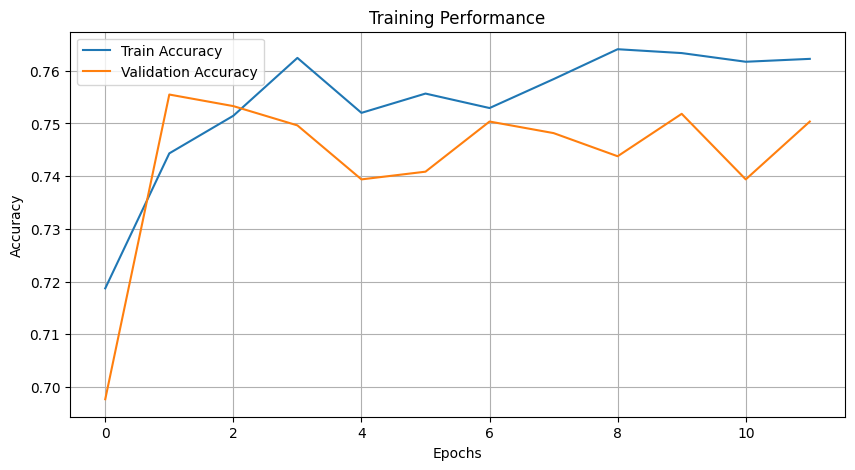

In [5]:
# ==============================
# 📈 5️⃣ Plot Training Performance
# ==============================

import matplotlib.pyplot as plt

def plot_training_history(history):
    """Plot accuracy and loss over training epochs."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training Performance")
    plt.grid(True)
    plt.show()

# Plot the results
plot_training_history(history)


2025-02-18 01:35:58.940460: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


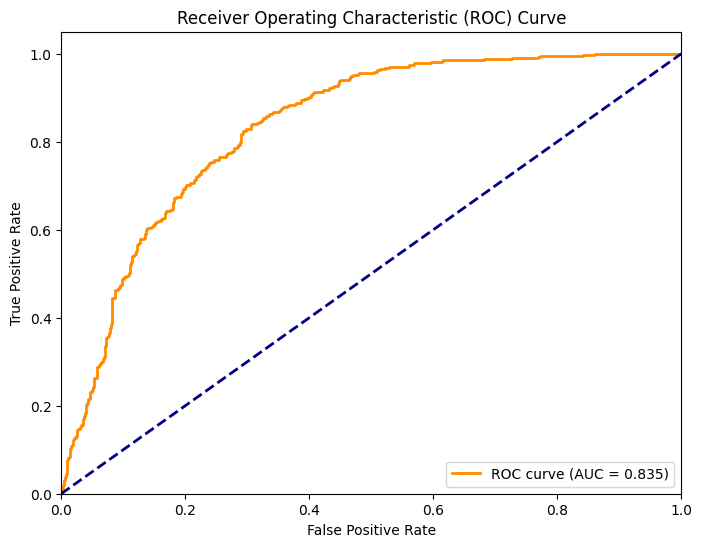

✅ Model AUC Score: 0.835


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, test_ds, input_dim):
    # Convert the dataset to a list so it can be reused.
    # This will unbatch the dataset, yielding tuples (features, labels).
    test_data = list(test_ds.unbatch().as_numpy_iterator())
    
    # Check if any data was extracted.
    if len(test_data) == 0:
        print("Test dataset is empty. Please check your data loading pipeline.")
        return
    
    # Unzip the data into features and labels
    test_features, test_labels = zip(*test_data)
    
    # Convert lists to NumPy arrays
    test_features = np.array(test_features).reshape(-1, input_dim)
    test_labels = np.array(test_labels).reshape(-1)
    
    # Make predictions on the test data
    y_pred = model.predict(test_features)
    
    # If your model has a single output, y_pred will be shape (n,1). Flatten if needed.
    if y_pred.ndim > 1 and y_pred.shape[1] == 1:
        y_pred = y_pred.flatten()
    
    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(test_labels, y_pred)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()
    
    print(f"✅ Model AUC Score: {roc_auc:.3f}")

# Call the function with the model and test dataset.
plot_roc_curve(best_model, test_ds, input_dim)
